In [2]:
import pandas as pd

df = pd.read_csv("../dataset/cleaned_college_faq.csv")

print(df.head())
print(df.shape)

   ID  Category      Question                                        Answer  \
0   1  Greeting            hi  Hello! Welcome to the College Query Chatbot.   
1   2  Greeting         hello                 Hi! How can I help you today?   
2   3  Greeting  good morning         Good Morning! Welcome to our college.   
3   4  Greeting  good evening           Good Evening! How can I assist you?   
4   5  Greeting           bye                   Thank you! Have a nice day.   

   Answer_Length  
0             44  
1             29  
2             37  
3             35  
4             27  
(101, 5)


In [3]:
X = df["Question"]
y = df["Category"]

print("Number of questions:", len(X))
print("Number of categories:", y.nunique())

print("\nCategories:")
print(y.unique())

Number of questions: 101
Number of categories: 10

Categories:
['Greeting' 'Admission' 'Courses' 'Library' 'Hostel' 'Placement' 'Fees'
 'Faculty' 'Examination' 'Campus']


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 80
Testing samples: 21


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (80, 93)
Testing TF-IDF shape: (21, 93)


In [6]:
from sklearn.naive_bayes import MultinomialNB

# Create the Naive Bayes model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train_tfidf, y_train)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [7]:
y_pred = nb_model.predict(X_test_tfidf)

print("Predicted Categories:")
print(y_pred)

Predicted Categories:
['Courses' 'Library' 'Library' 'Hostel' 'Examination' 'Placement'
 'Library' 'Admission' 'Library' 'Library' 'Library' 'Library' 'Faculty'
 'Hostel' 'Admission' 'Library' 'Examination' 'Fees' 'Library' 'Fees'
 'Library']


In [8]:
results = pd.DataFrame({
    "Question": X_test.values,
    "Actual Category": y_test.values,
    "Predicted Category": y_pred
})

results["Correct"] = (
    results["Actual Category"] == results["Predicted Category"]
)

results

,Question,Actual Category,Predicted Category,Correct
0,electrical engineering,Courses,Courses,True
1,principal,Faculty,Library,False
2,lateral entry,Admission,Library,False
3,hostel rooms,Hostel,Hostel,True
4,supplementary exams,Examination,Examination,True
5,highest package,Placement,Placement,True
6,library rules,Library,Library,True
7,college timings,Campus,Admission,False
8,book issue,Library,Library,True
9,ncc,Campus,Library,False


In [9]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", round(accuracy * 100, 2), "%")

Accuracy: 0.6190476190476191
Accuracy Percentage: 61.9 %


In [10]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

   Admission       0.50      0.50      0.50         2
      Campus       0.00      0.00      0.00         2
     Courses       1.00      0.50      0.67         2
 Examination       1.00      1.00      1.00         2
     Faculty       1.00      0.50      0.67         2
        Fees       1.00      1.00      1.00         2
    Greeting       0.00      0.00      0.00         2
      Hostel       1.00      1.00      1.00         2
     Library       0.30      1.00      0.46         3
   Placement       1.00      0.50      0.67         2

    accuracy                           0.62        21
   macro avg       0.68      0.60      0.60        21
weighted avg       0.66      0.62      0.59        21



C:\Users\MYPC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\MYPC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\MYPC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classif

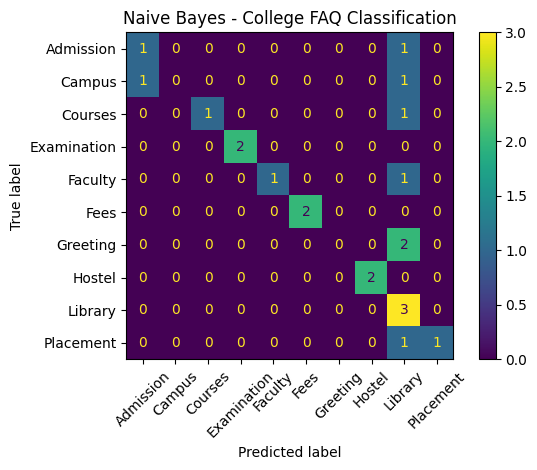

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45
)

plt.title("Naive Bayes - College FAQ Classification")
plt.tight_layout()
plt.show()

In [12]:
new_question = ["What programs are available in the college?"]

new_question_tfidf = tfidf.transform(new_question)

prediction = nb_model.predict(new_question_tfidf)

print("Question:", new_question[0])
print("Predicted Category:", prediction[0])

Question: What programs are available in the college?
Predicted Category: Admission


In [13]:
test_questions = [
    "What courses are offered?",
    "Which programs are available?",
    "How can I apply for admission?",
    "What hostel facilities are available?",
    "Which companies recruit students?",
    "What are the college fees?",
    "When are examinations conducted?"
]

test_tfidf = tfidf.transform(test_questions)

predictions = nb_model.predict(test_tfidf)

for question, category in zip(test_questions, predictions):
    print("Question:", question)
    print("Predicted Category:", category)
    print("-" * 50)

Question: What courses are offered?
Predicted Category: Library
--------------------------------------------------
Question: Which programs are available?
Predicted Category: Library
--------------------------------------------------
Question: How can I apply for admission?
Predicted Category: Admission
--------------------------------------------------
Question: What hostel facilities are available?
Predicted Category: Hostel
--------------------------------------------------
Question: Which companies recruit students?
Predicted Category: Placement
--------------------------------------------------
Question: What are the college fees?
Predicted Category: Admission
--------------------------------------------------
Question: When are examinations conducted?
Predicted Category: Library
--------------------------------------------------


In [14]:
def predict_category(question):
    question_tfidf = tfidf.transform([question])
    prediction = nb_model.predict(question_tfidf)
    return prediction[0]

In [15]:
def get_answer(question):
    category = predict_category(question)

    category_data = df[df["Category"] == category]

    if category_data.empty:
        return "Sorry, I could not find an answer."

    return category_data.iloc[0]["Answer"]

In [16]:
question = "What programs are available?"

category = predict_category(question)
answer = get_answer(question)

print("You:", question)
print("Predicted Category:", category)
print("Bot:", answer)

You: What programs are available?
Predicted Category: Library
Bot: The library is open from 9 AM to 5 PM.


In [17]:
results.to_csv(
    "../results/chatbot_test_results.csv",
    index=False
)

print("Chatbot test results saved!")

Chatbot test results saved!


In [18]:
with open("../results/classification_report.txt", "w") as f:
    f.write(report)

print("Classification report saved!")

Classification report saved!


In [22]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\MYPC\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


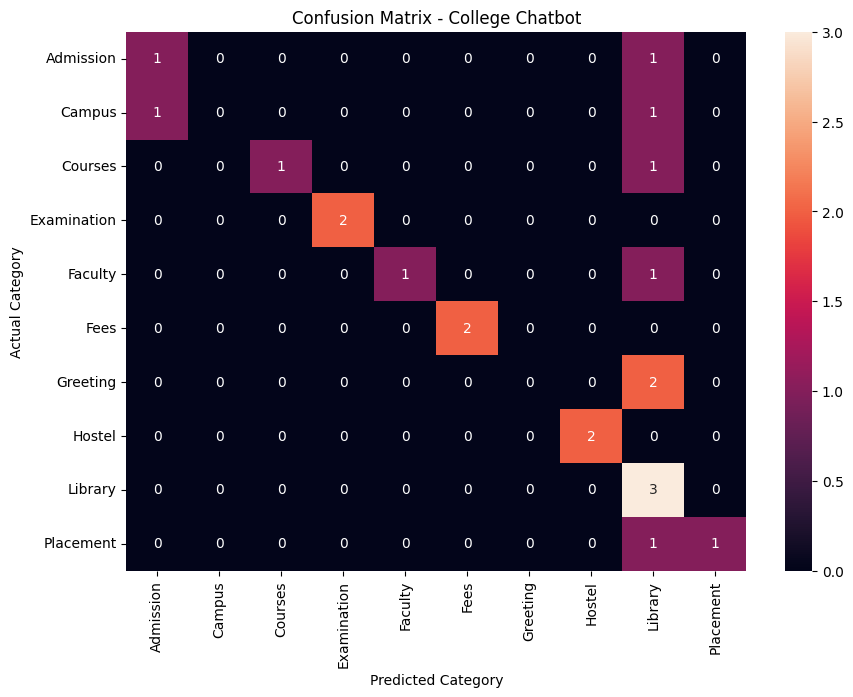

In [23]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique())
)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.title("Confusion Matrix - College Chatbot")

plt.show()

In [24]:
import sys
print(sys.executable)

C:\Users\MYPC\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe
